# SEMAI — results notebook

A thin wrapper. The reproducible source is the scripts in `scripts/`; this notebook just re-runs them in order and shows every figure and the headline numbers, read straight from `results/*.json`.

Order: Penang data → SEMAI Forecast → "Why VPD, not humidity" → Wilt Watch → rig-photo check → today's outlook (skipped when offline).

In [1]:
import os, sys, json, subprocess, time
ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
os.chdir(ROOT)
PY = sys.executable
print("repo:", ROOT)
print("python:", PY)

def run(script, *args, allow_fail=False):
    t0 = time.time()
    p = subprocess.run([PY, os.path.join(ROOT, "scripts", script), *args], capture_output=True, text=True)
    print("$ python scripts/%s %s   (exit %d, %.0f s)" % (script, " ".join(args), p.returncode, time.time() - t0))
    print(p.stdout[-6000:])
    if p.returncode != 0:
        print(p.stderr[-3000:])
        if not allow_fail:
            raise SystemExit(script + " failed")

def show(name):
    from IPython.display import Image, display
    path = os.path.join(ROOT, "results", name)
    if os.path.exists(path):
        display(Image(filename=path, width=900))
    else:
        print("missing figure:", name)

def load_json(name):
    path = os.path.join(ROOT, "results", name)
    if not os.path.exists(path):
        print("missing:", name)
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)

repo: C:\Dev\semai-ml
python: C:\Dev\semai-ml\.venv\Scripts\python.exe


## 1 · Penang weather (Open-Meteo / ERA5), cached

In [2]:
from semai import penang_data
df = penang_data.load()
print(len(df), "hourly rows,", df.time.min(), "to", df.time.max())
print(penang_data.meta())
df.describe().T

26304 hourly rows, 2023-01-01 00:00:00 to 2025-12-31 23:00:00
{'url': 'https://archive-api.open-meteo.com/v1/archive?latitude=5.4482&longitude=100.29&start_date=2023-01-01&end_date=2025-12-31&hourly=temperature_2m,relative_humidity_2m&timezone=Asia%2FKuala_Lumpur', 'fetched_at_utc': '2026-09-25T03:49:38Z', 'rows': 26304, 'expected_rows': 26304, 'latitude': 5.448155, 'longitude': 100.28998, 'timezone': 'Asia/Kuala_Lumpur', 'elevation_m': 157.0, 'source': 'Open-Meteo Historical Weather API (ERA5 reanalysis), CC BY 4.0'}


,count,mean,min,25%,50%,75%,max,std
time,26304,2024-07-01 23:30:00,2023-01-01 00:00:00,2023-10-01 23:45:00,2024-07-01 23:30:00,2025-04-01 23:15:00,2025-12-31 23:00:00,NaN
t,26304.0,26.807539,21.4,25.0,26.5,28.3,35.0,2.220342
rh,26304.0,84.070293,28.0,77.0,86.0,94.0,100.0,11.864262
vpd,26304.0,0.616372,0.0,0.194643,0.465066,0.866086,3.724525,0.544684


## 2 · SEMAI Forecast — train on 2023–2024, test on 2025 only

In [3]:
run("train_forecast.py")

$ python scripts/train_forecast.py    (exit 0, 5 s)
data rows=26304  2023-01-01 00:00:00 .. 2025-12-31 23:00:00
[PASS] hourly series is continuous: every step is 1 h
[PASS] feature names/order: hour_sin, hour_cos, doy_sin, doy_cos, t, rh, vpd, t_lag1, t_lag2, t_lag3, rh_lag1, rh_lag2, rh_lag3, vpd_lag1, vpd_lag2, vpd_lag3, dvpd
rows after dropping NaN features/labels: 26299 (dropped 5)
train rows=17539 (2023-01-01 03:00:00 .. 2024-12-31 21:00:00), dropped for leakage=2
TEST SIZE = 8758 rows (2025-01-01 00:00:00 .. 2025-12-31 21:00:00)
[PASS] every test row is in 2025: n_test=8758
[PASS] no train row is in 2025: n_train=17539
[PASS] no train label uses a 2025 hour: last train hour 2024-12-31 21:00:00, its label window ends 2024-12-31 23:00:00; 2 train rows dropped
[PASS] train and test are disjoint: 
[PASS] test set = all 2025 rows with a defined label: 8758 of 8760 2025 hours; the 2 last hours of 2025-12-31 have no label (t+2 is outside the data)
positive rate train=0.1237 test=0.2431


,who,accuracy,f1,precision,recall,auc
0,always_no,0.756908,0.000000,0.000000,0.000000,NaN
1,persistence,0.897351,0.772117,0.838656,0.715359,0.835580
2,climatology,0.840831,0.702391,0.643836,0.772663,0.906912
3,model,0.938000,0.864959,0.919133,0.816815,0.981187


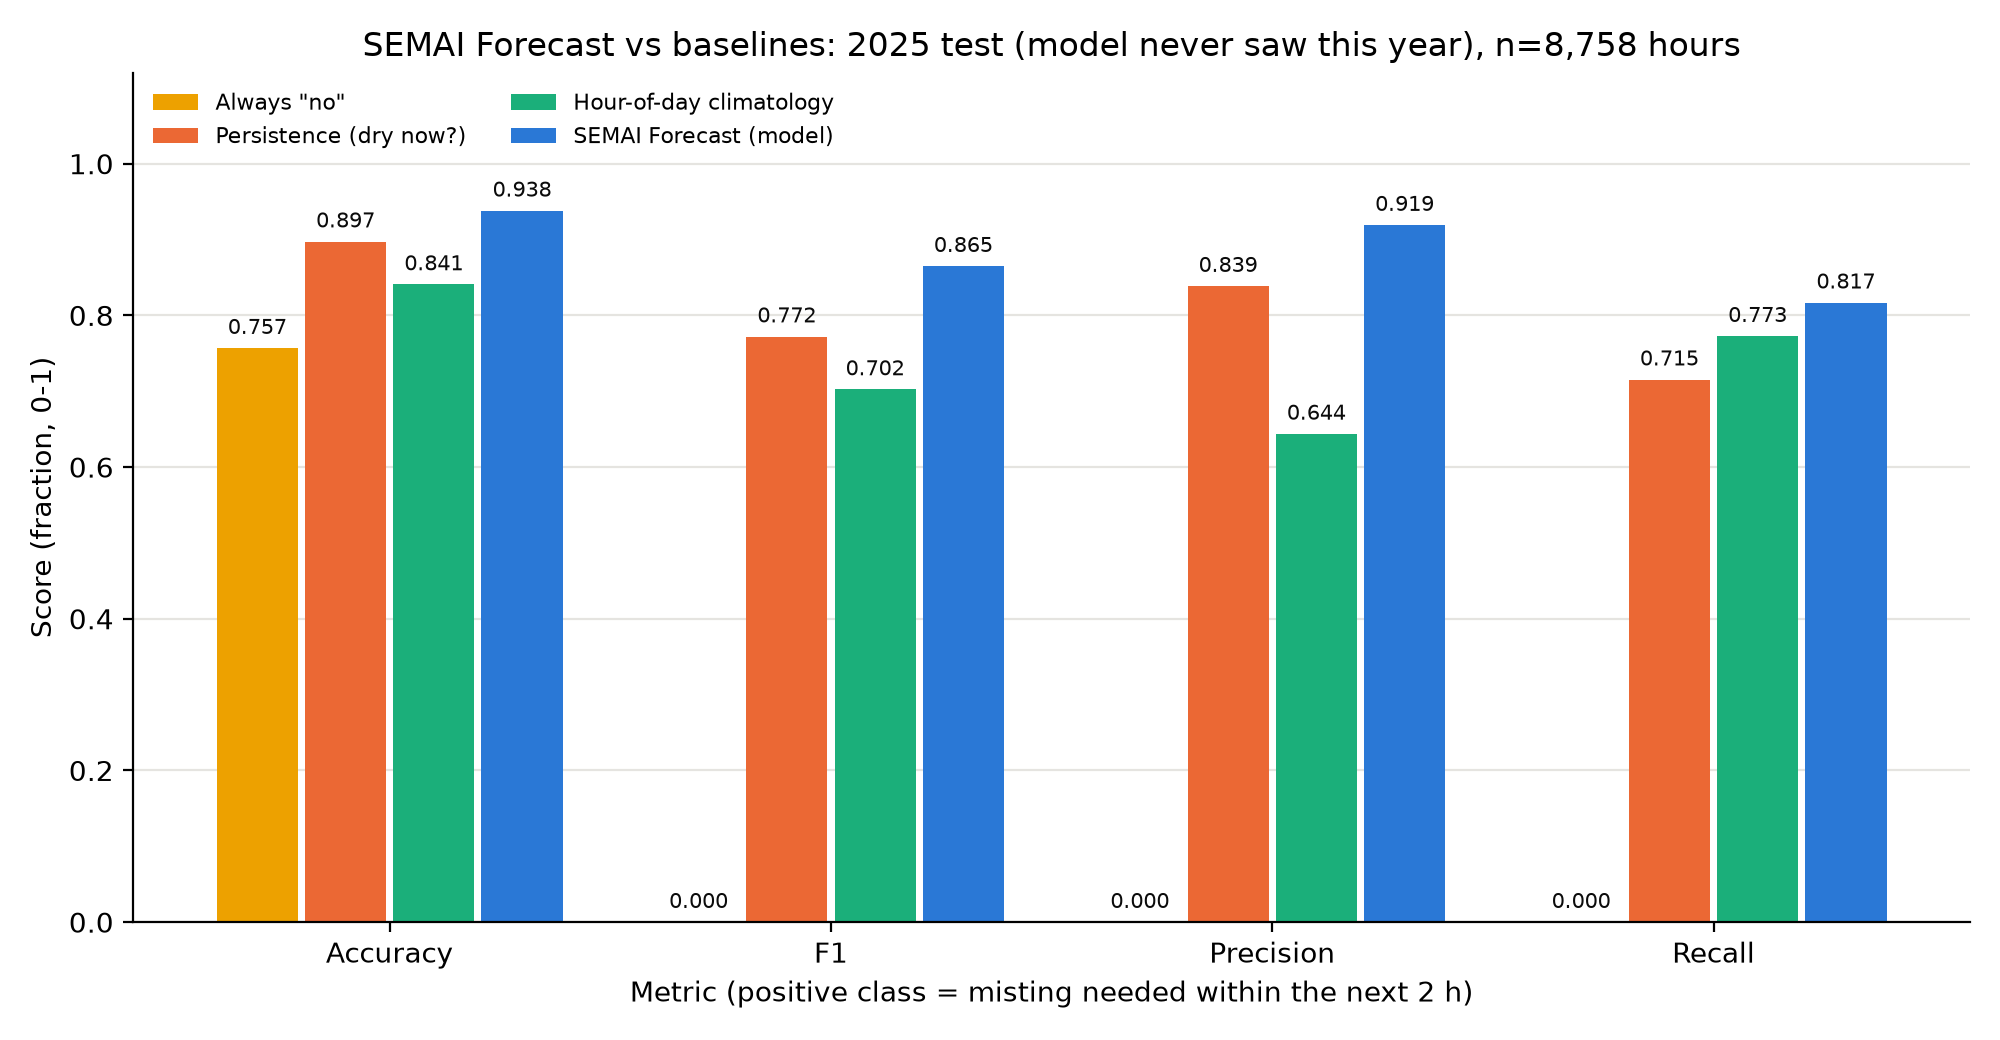

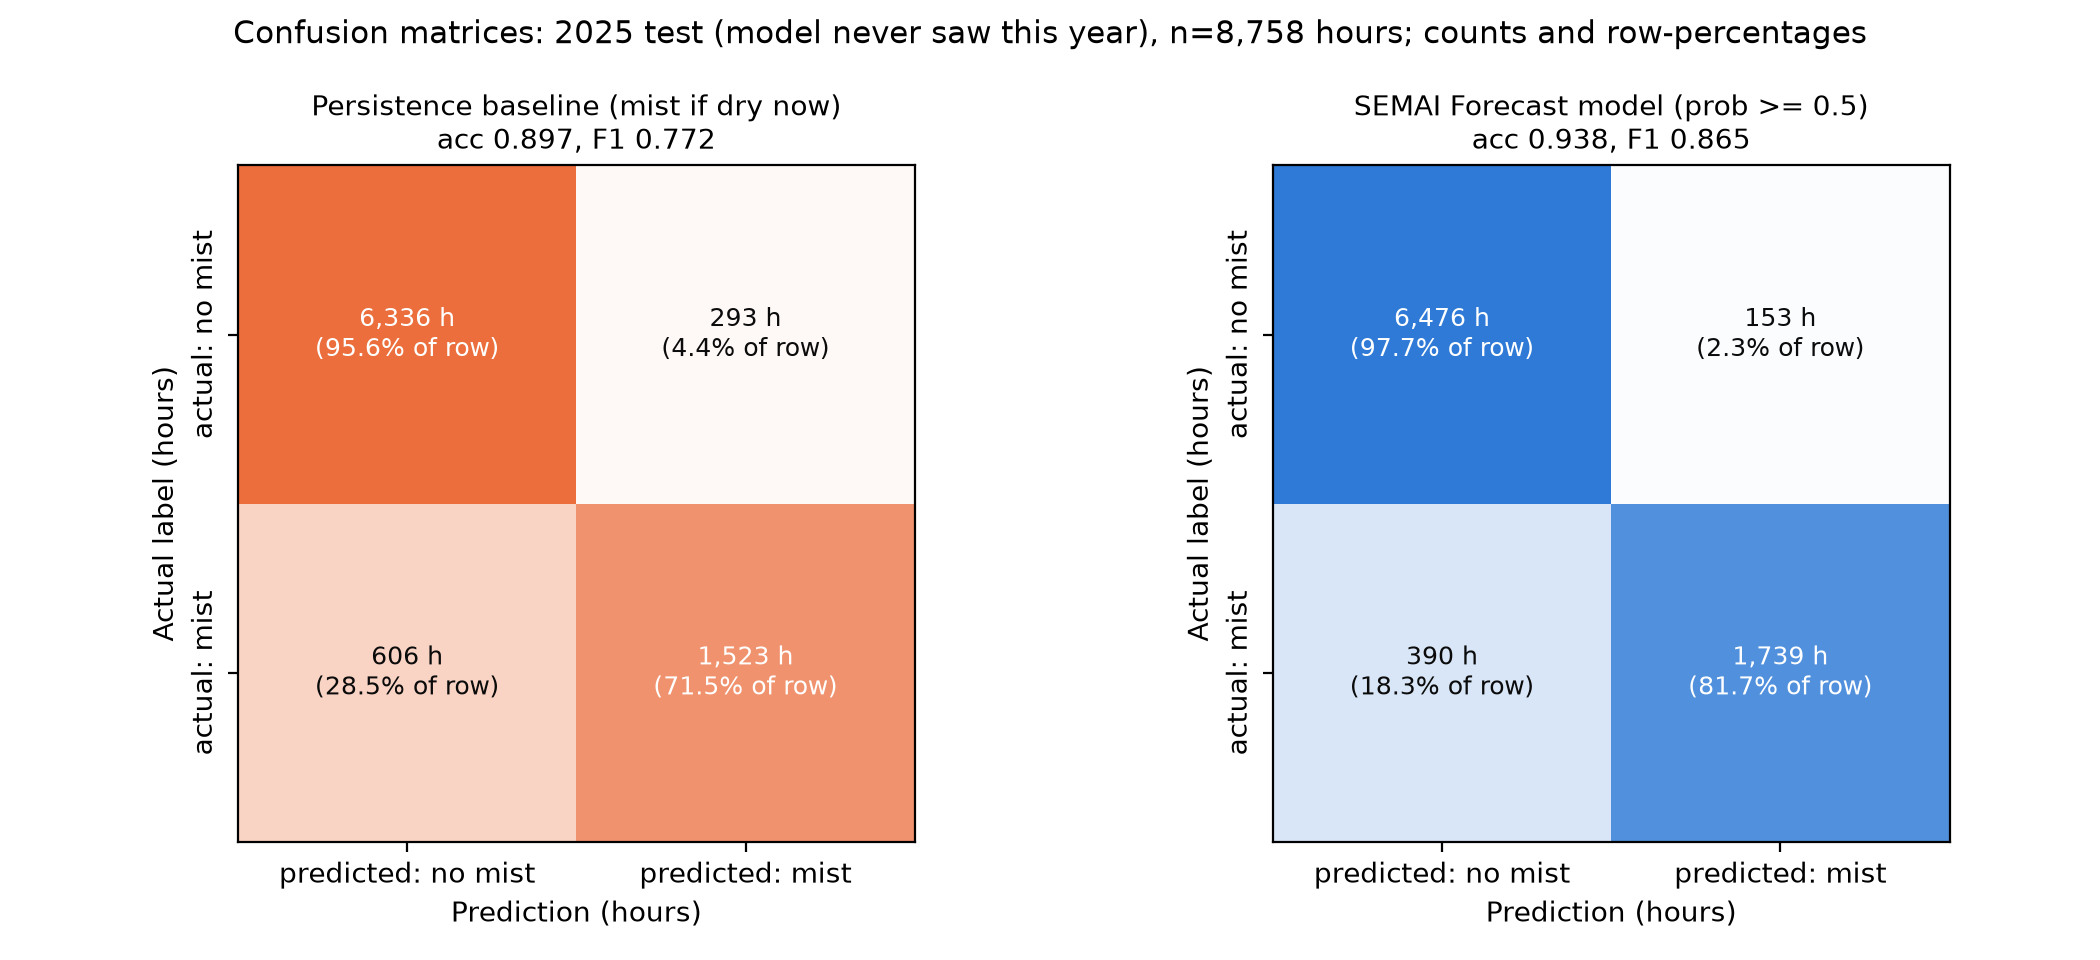

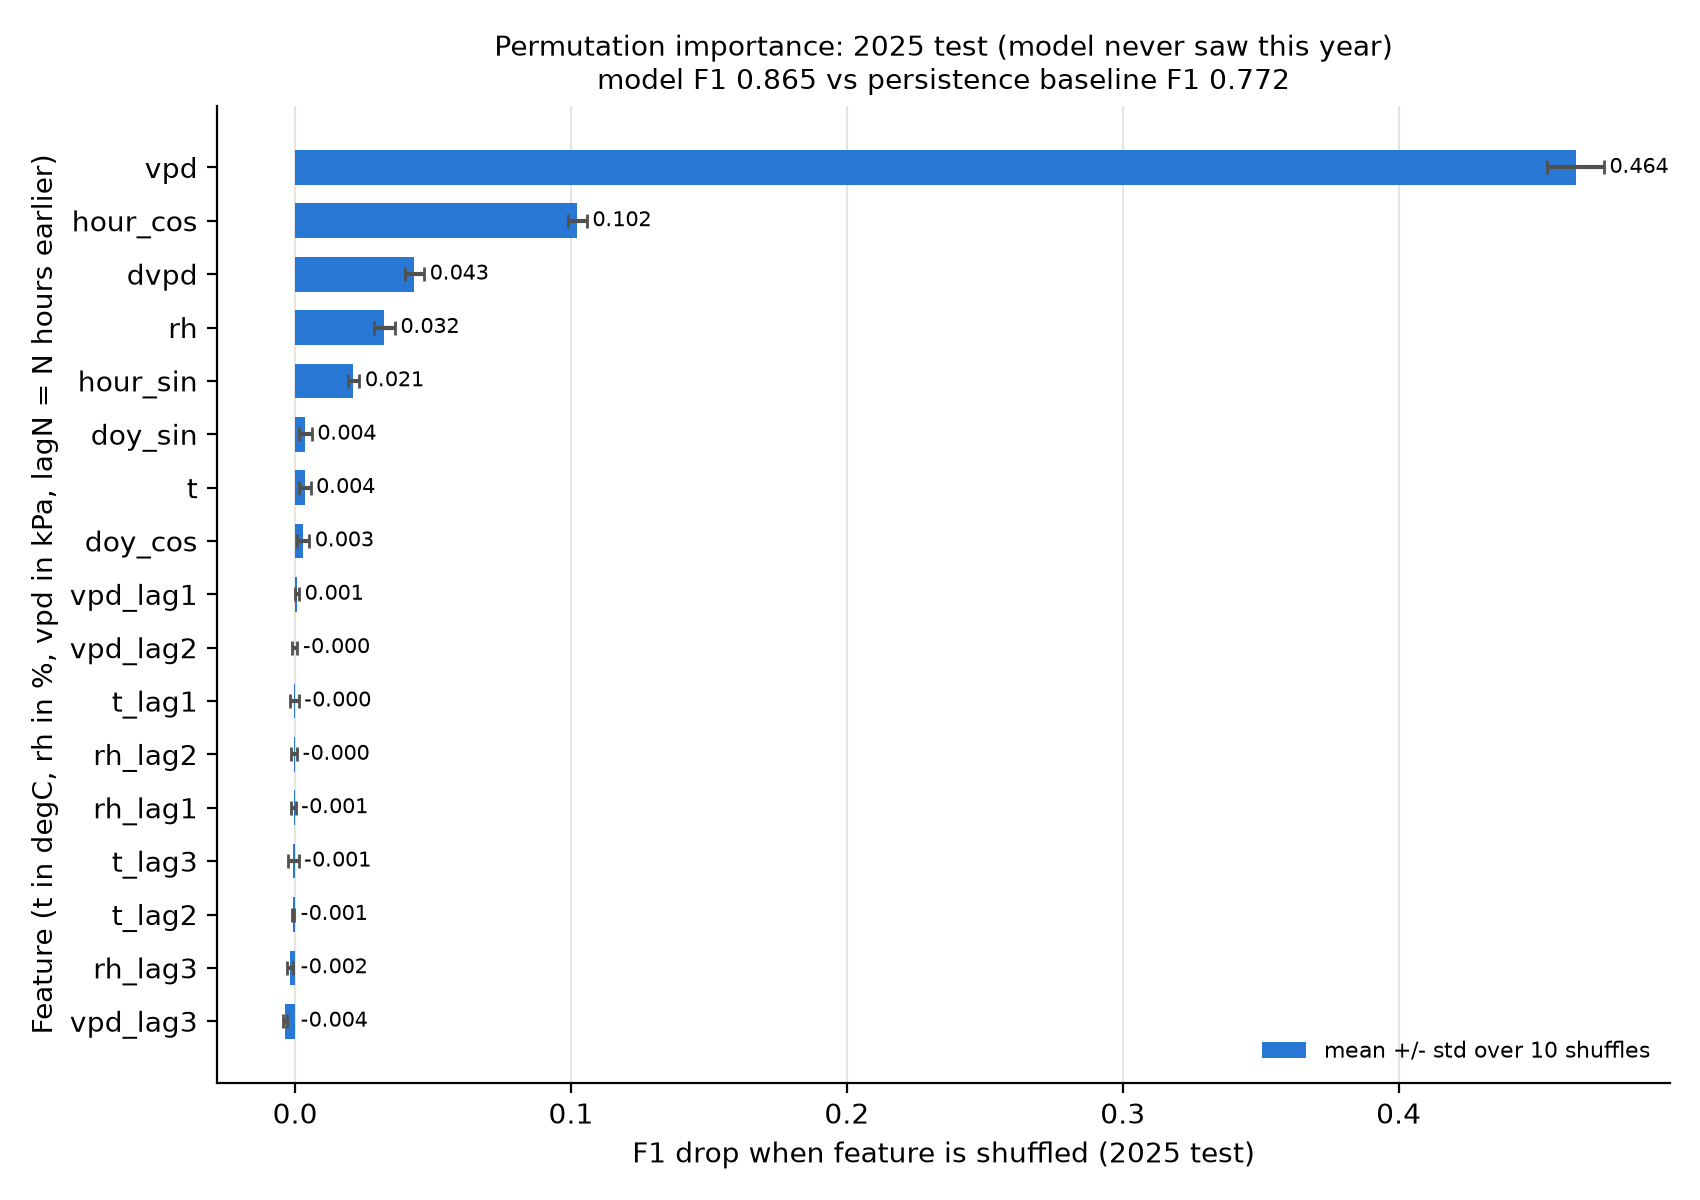

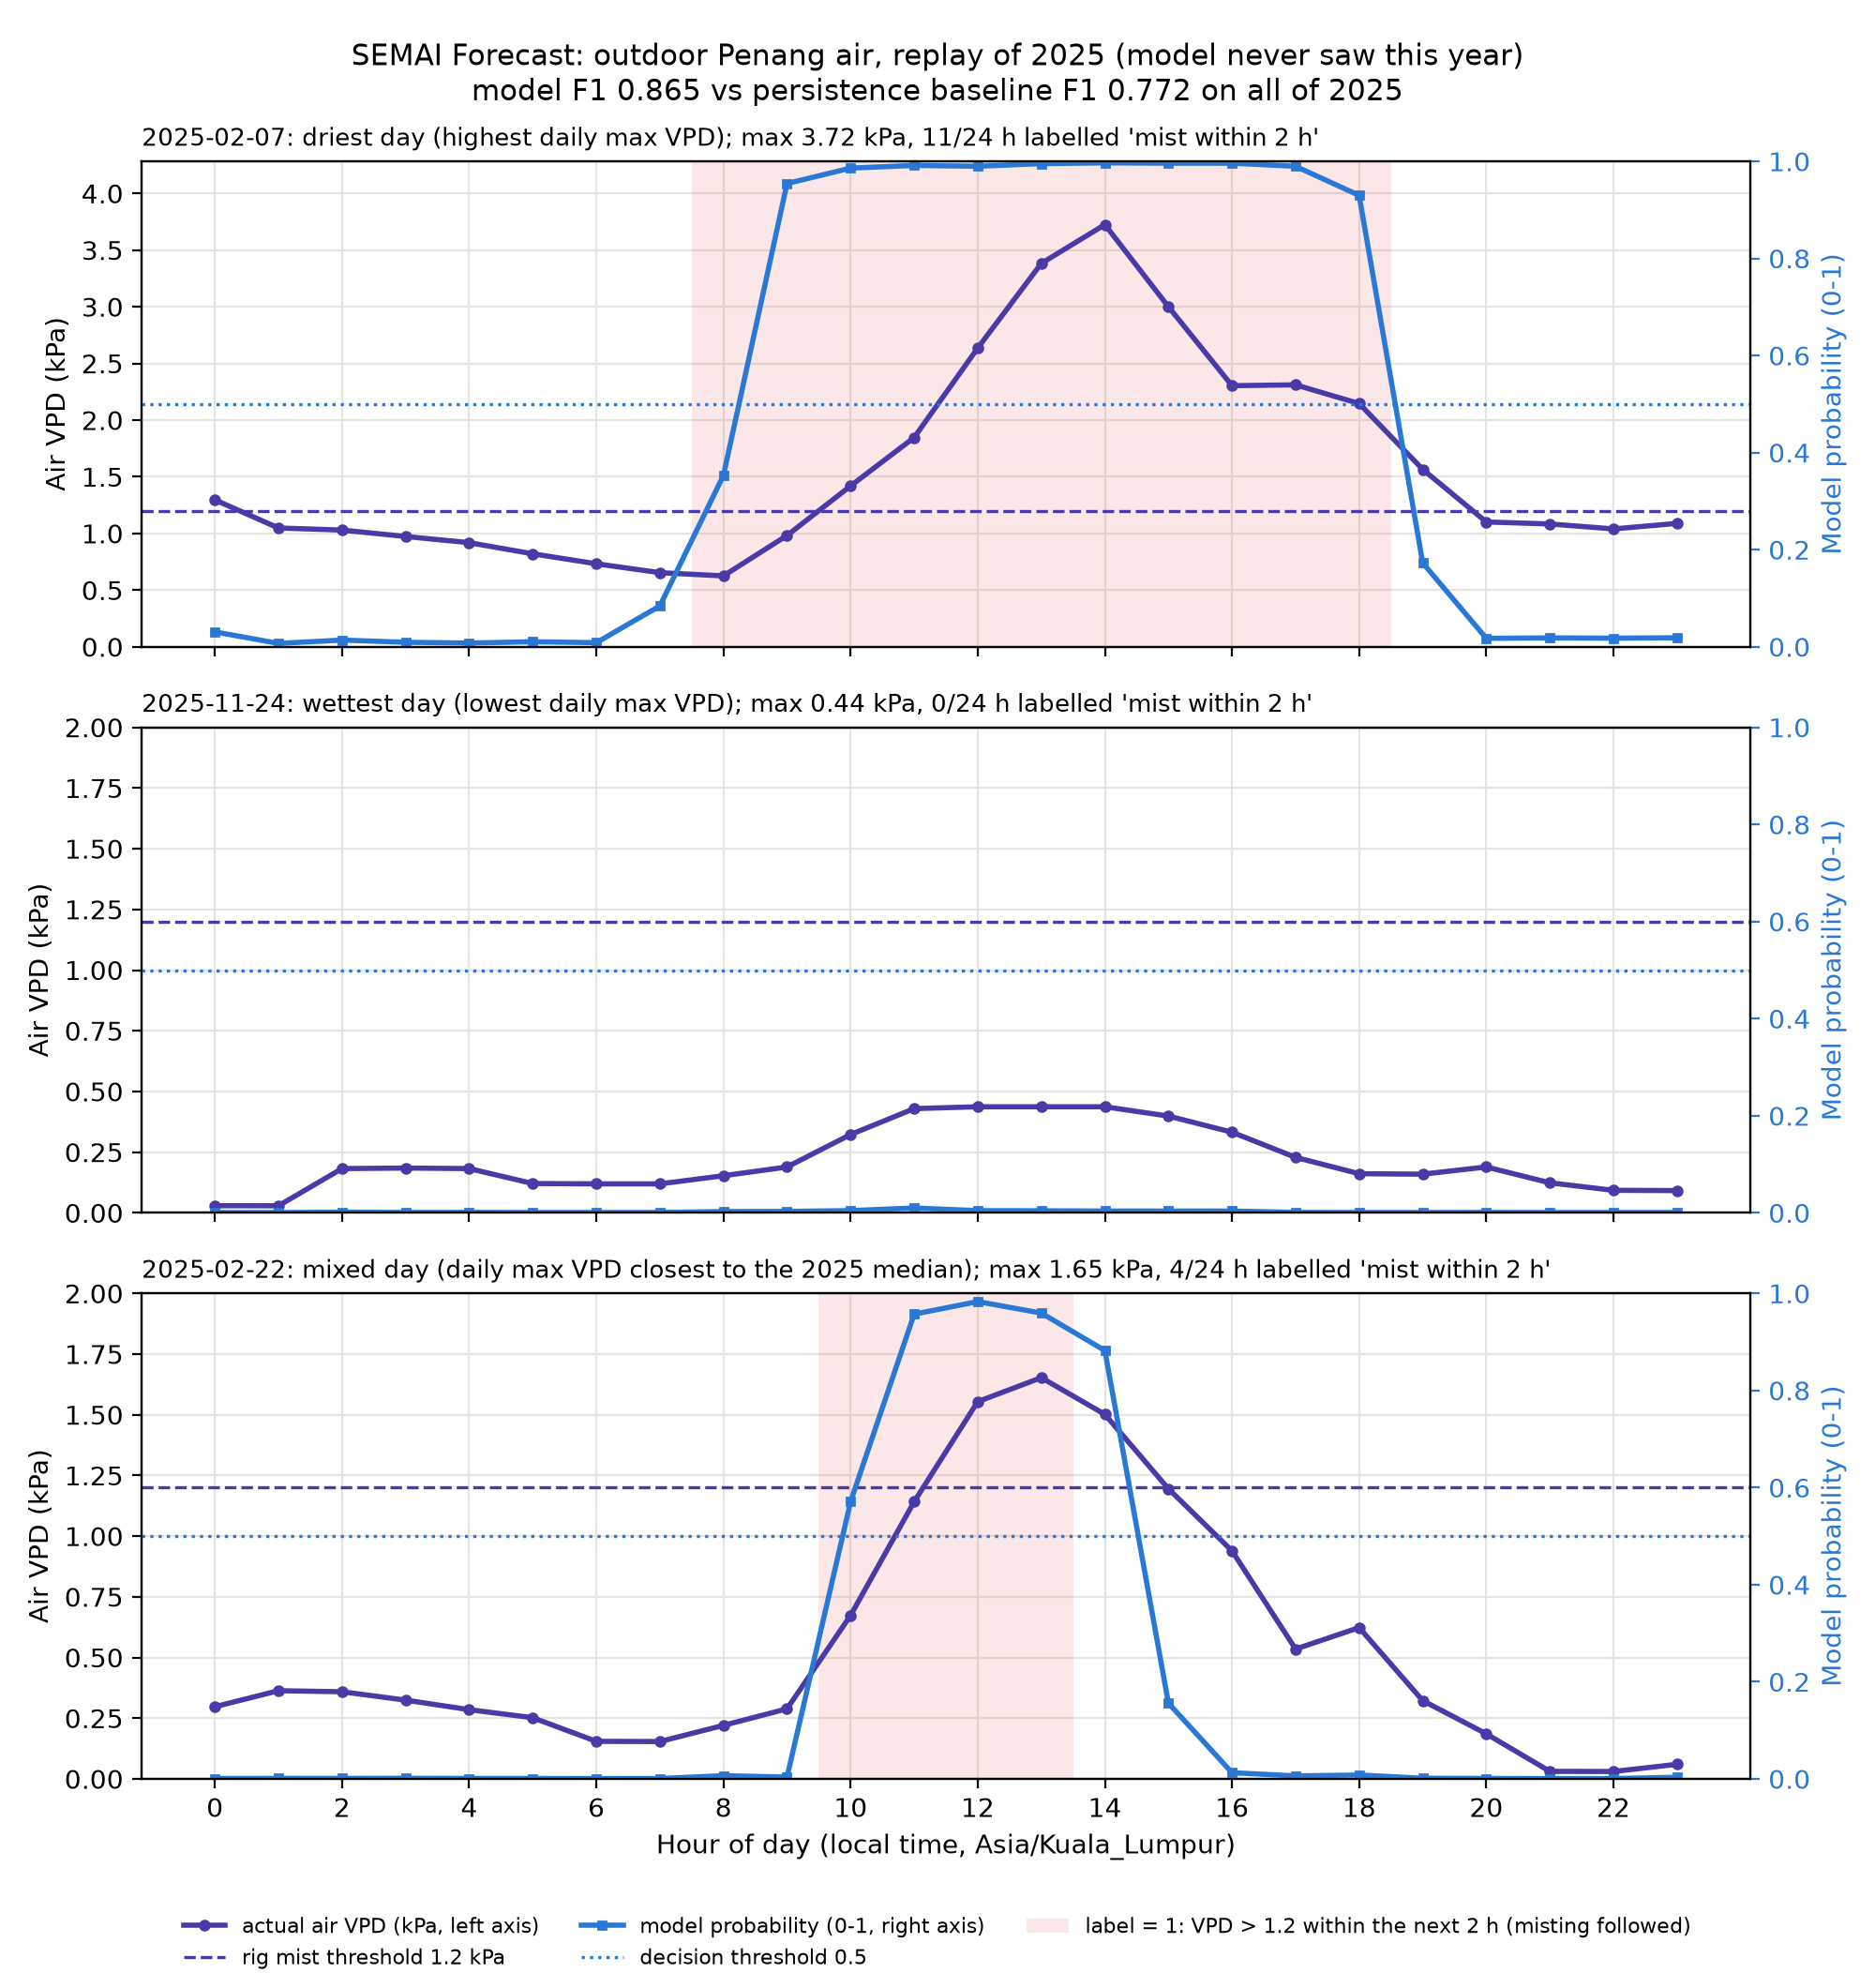

In [4]:
m = load_json("forecast_metrics.json")
if m:
    import pandas as pd
    rows = []
    for k in ("always_no", "persistence", "climatology", "model"):
        mm = m["metrics"].get(k, {})
        rows.append((k, mm.get("accuracy"), mm.get("f1"), mm.get("precision"), mm.get("recall"), mm.get("auc")))
    display(pd.DataFrame(rows, columns=["who", "accuracy", "f1", "precision", "recall", "auc"]))
for f in ["F1_model_vs_baselines.png", "F2_confusion_2025.png", "F3_feature_importance.png", "F4_replay_3days.png"]:
    show(f)

## 3 · Why VPD, not humidity (same data, no ML)

In [5]:
run("why_vpd.py")

$ python scripts/why_vpd.py    (exit 0, 1 s)
hours: 26304  (fetched 2026-09-25T03:49:38Z)
rig states (hysteresis): DRY 15.5%, OPTIMAL 18.3%, SATURATED 66.2%
bands (no hysteresis): >1.2 13.7%, 0.8-1.1 11.6%, <0.6 59.9%
RH<60 rule misses 2428 of 3604 dry-stress hours (67.4%), false alarms 0
typical missed hour: 30.1 degC, 66% RH, 1.41 kPa
dry share peaks at 50.2% at 14:00
wrote
  C:\Dev\semai-ml\results\why_vpd.json
  C:\Dev\semai-ml\results\W1_rig_states_penang.png
  C:\Dev\semai-ml\results\W2_rh_rule_misses.png
  C:\Dev\semai-ml\results\W3_dry_by_hour.png



{
 "computed_at_utc": "2026-09-25T04:39:56Z",
 "seed": 0,
 "script": "scripts/why_vpd.py"
}


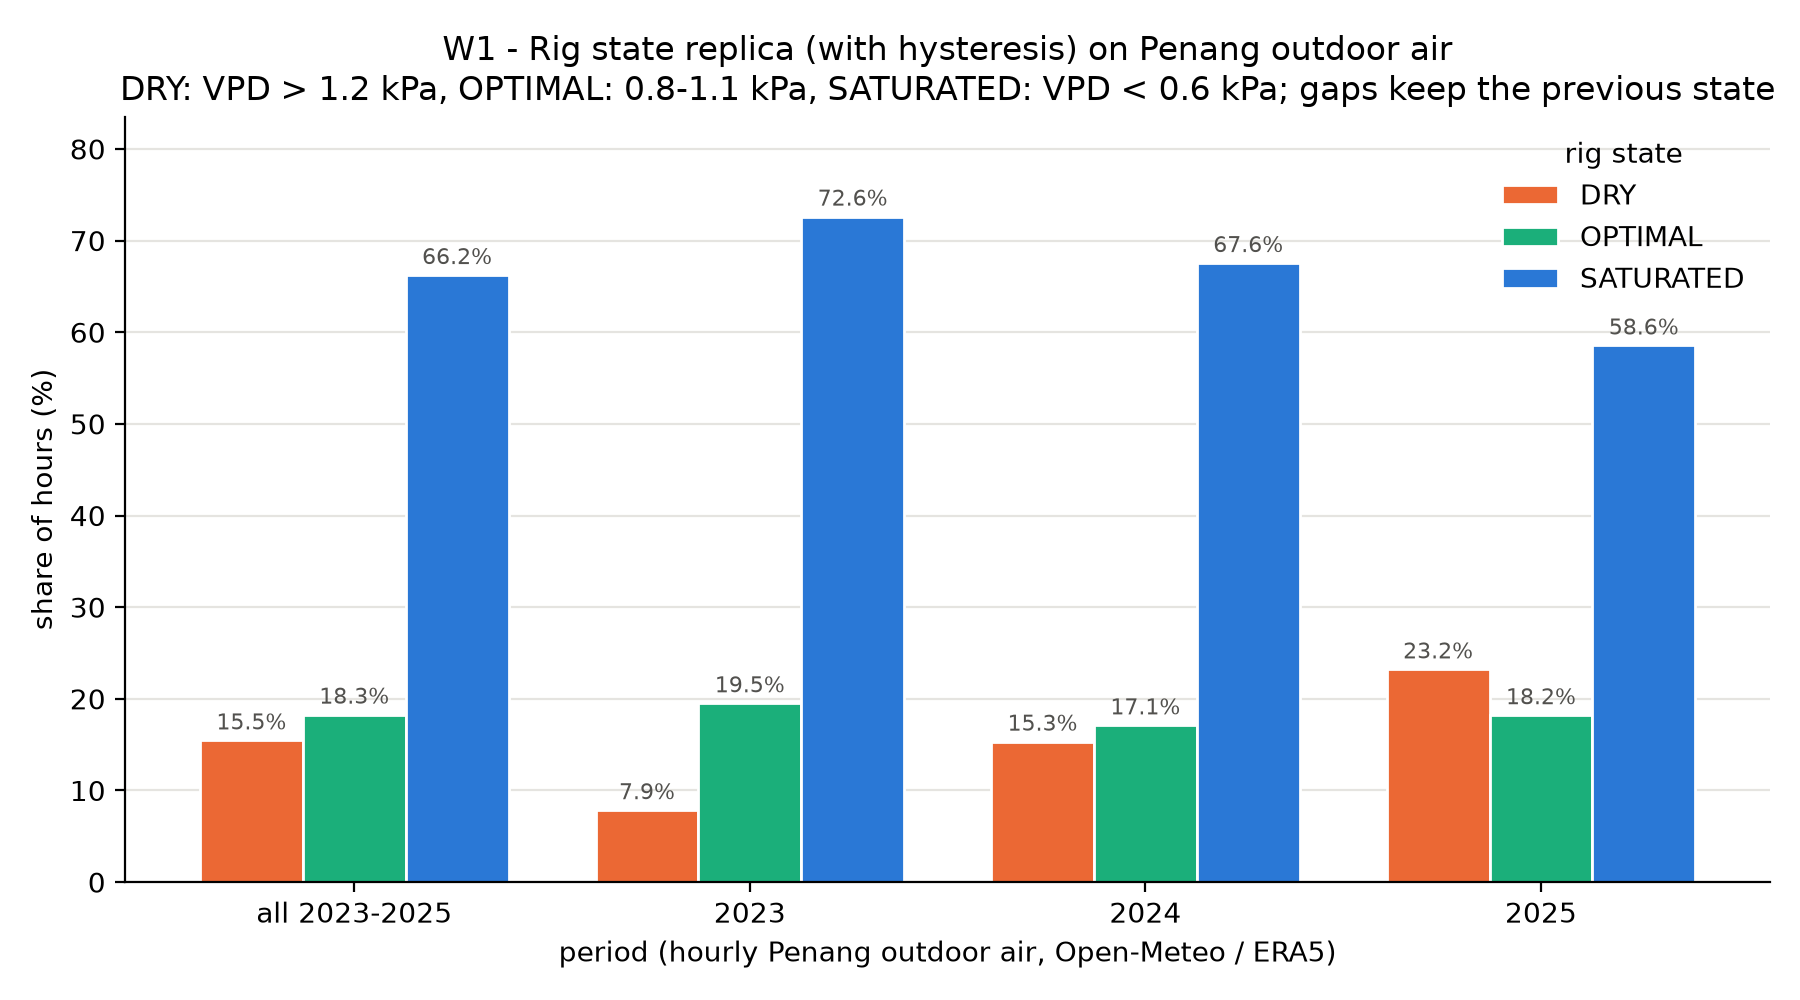

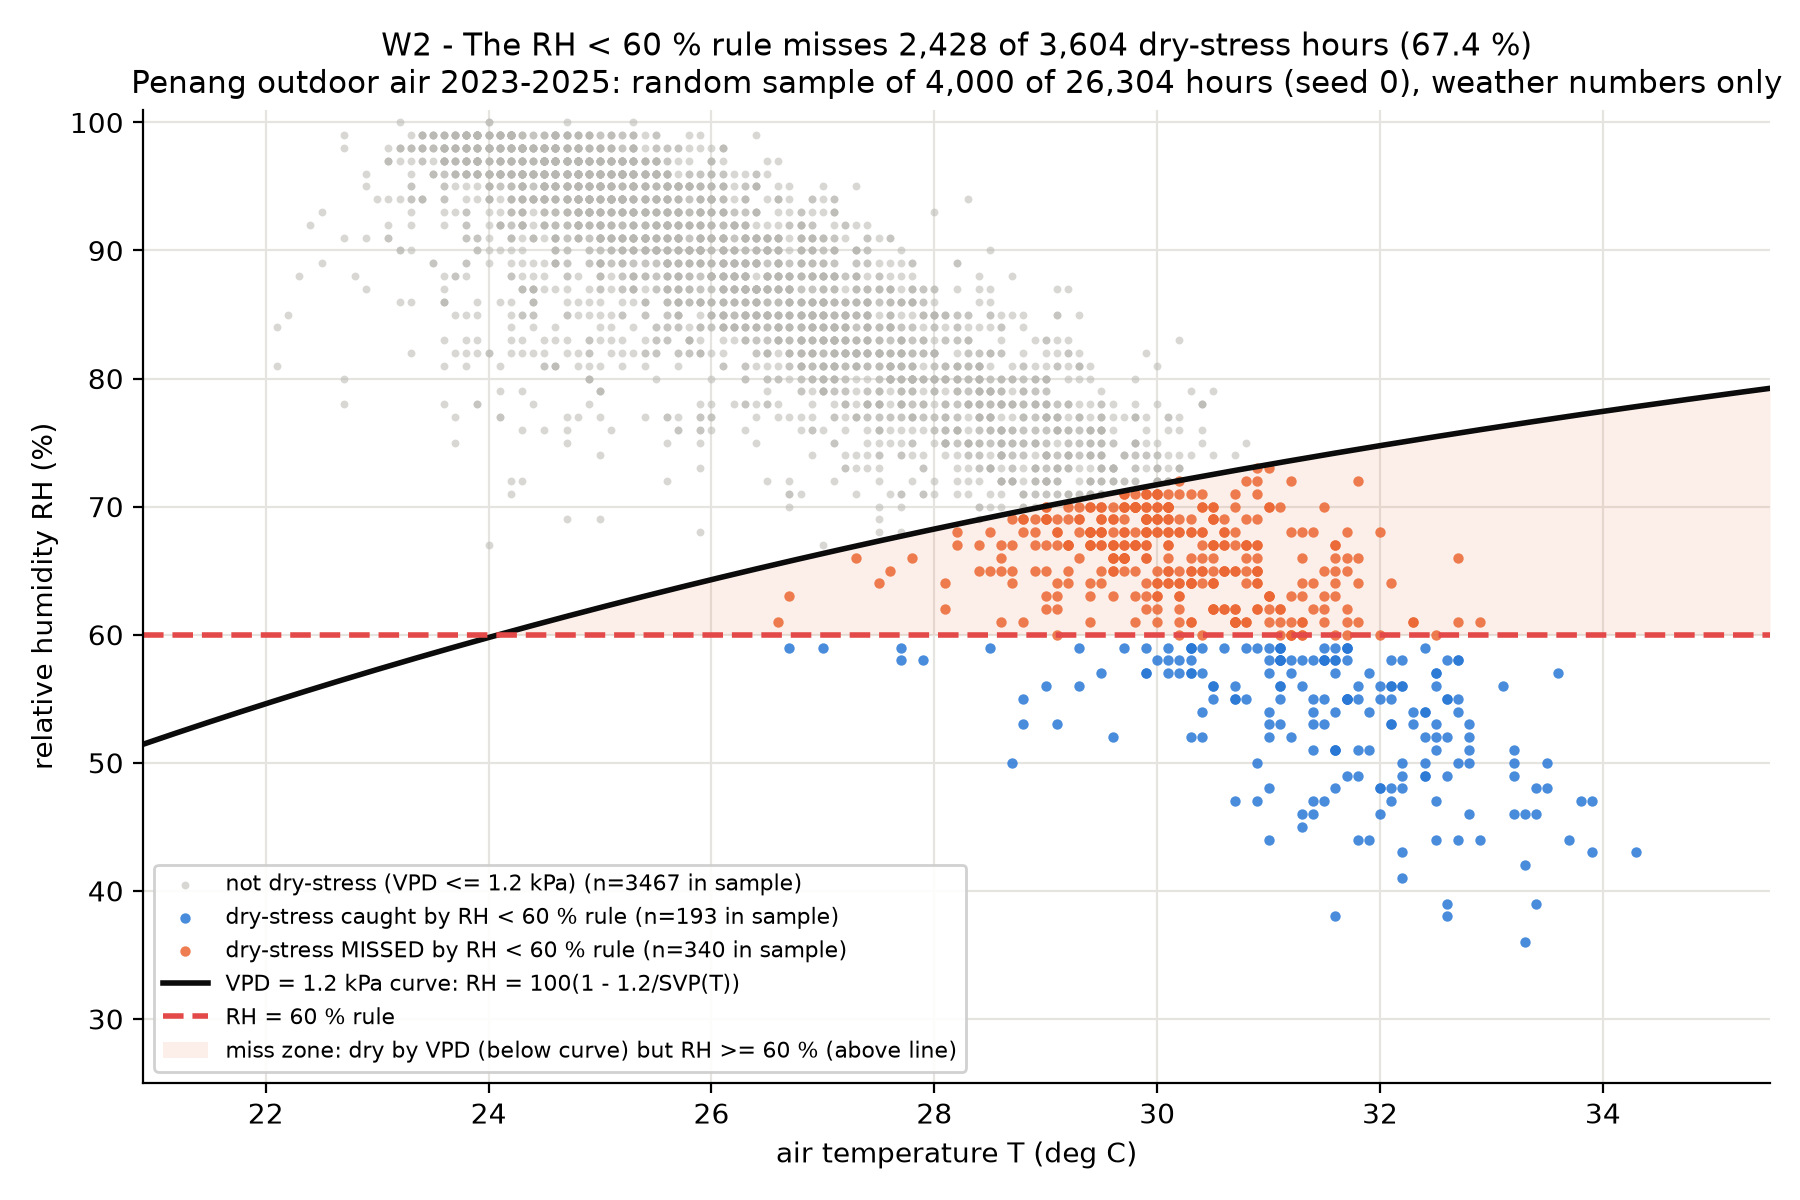

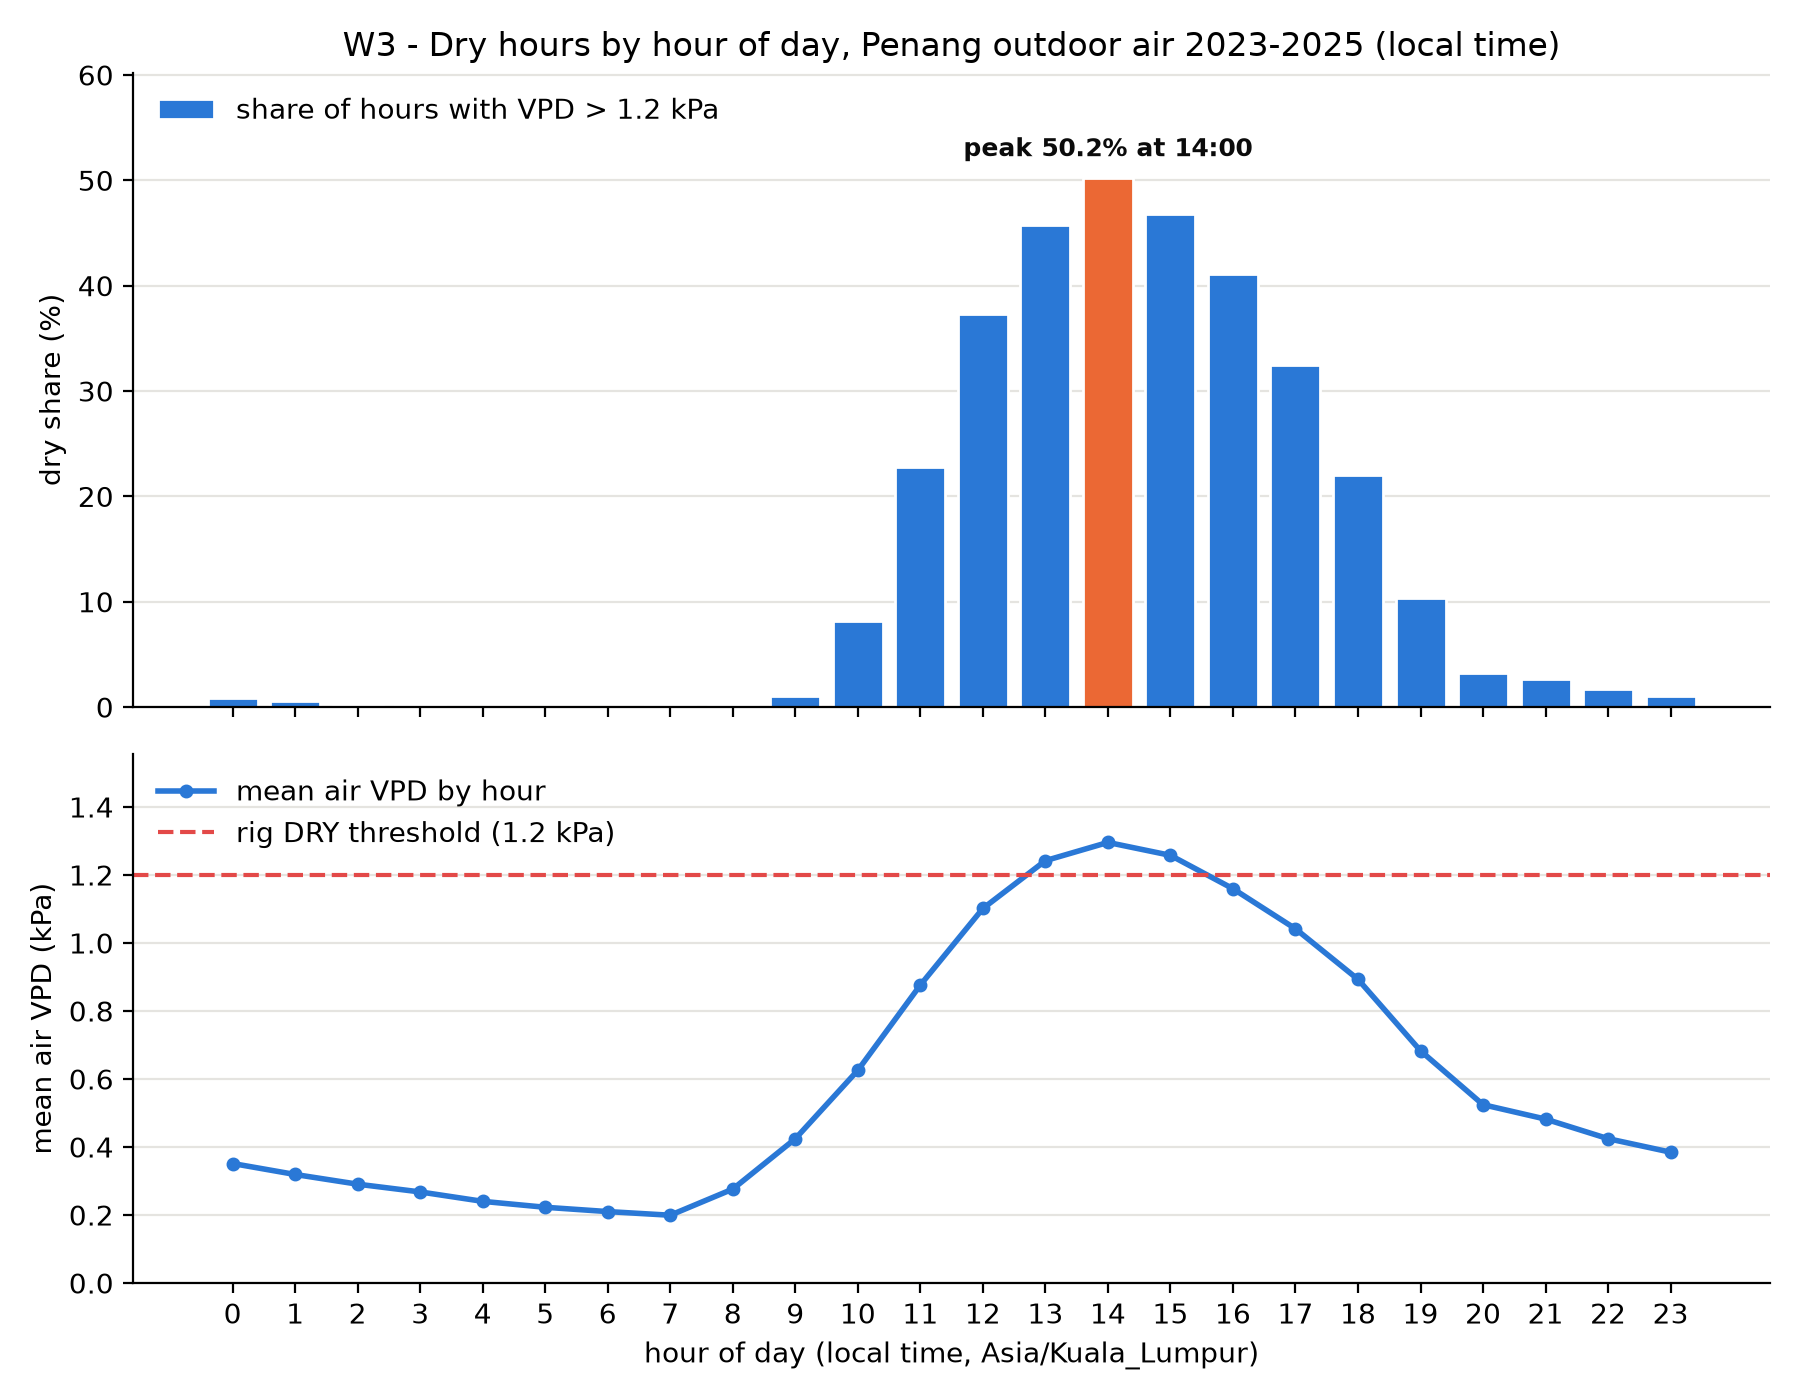

In [6]:
w = load_json("why_vpd.json")
if w:
    print(json.dumps({k: v for k, v in w.items() if not isinstance(v, (list, dict))}, indent=1)[:2000])
for f in ["W1_rig_states_penang.png", "W2_rh_rule_misses.png", "W3_dry_by_hour.png"]:
    show(f)

## 4 · SEMAI Wilt Watch — grouped 5-fold CV vs naive, baseline 50 %

In [7]:
run("train_wilt.py")
run("eval_rig_frames.py")

$ python scripts/train_wilt.py    (exit 0, 5 s)
[OK ] dataset has 904 images (452/452) n=904 healthy=452 wilted=452
feature cache hit: C:\Dev\semai-ml\data\wilt_features.npz (904, 960)
[OK ] feature matrix finite shape=(904, 960)
[OK ] feature dim 960 dim=960
[OK ] MobileNet weights cached in torch hub C:\Users\seana/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth
duplicates: 71 pairs over 124 images, 839 groups (59 with 2+), largest 3, 0 label mismatches
[OK ] no label-mismatched duplicate pairs 0 mismatches
[OK ] grouped CV: no duplicate group in both train and test of any fold 5 folds checked
grouped CV:
  grouped fold 0: n_test=181 acc=0.8343
  grouped fold 1: n_test=181 acc=0.8232
  grouped fold 2: n_test=181 acc=0.8232
  grouped fold 3: n_test=181 acc=0.8453
  grouped fold 4: n_test=180 acc=0.8500
naive CV:
  naive fold 0: n_test=181 acc=0.8564
  naive fold 1: n_test=181 acc=0.8619
  naive fold 2: n_test=181 acc=0.8177
  naive fold 3: n_test=181 acc=0.8729
  naive fo

{
 "part": "SEMAI Wilt Watch",
 "trained_at_utc": "2026-09-25T04:40:00+00:00",
 "seed": 0,
 "rig_eval": "see results/wilt_rig_eval.json (scripts/eval_rig_frames.py)",
 "extraction_seconds": 13.56,
 "total_script_seconds": 2.9
}
{'status': 'pending — no rig photos captured yet', 'n_healthy': 0, 'n_wilted': 0, 'baseline_accuracy': 0.5, 'roi': 0.7, 'folders': ['data/rig_frames/healthy', 'data/rig_frames/wilted'], 'how_to': 'capture ~30 healthy and ~30 wilted frames with the console buttons, then re-run python scripts/eval_rig_frames.py (SPEC §10)', 'checked_at_utc': '2026-09-25T04:40:01+00:00'}


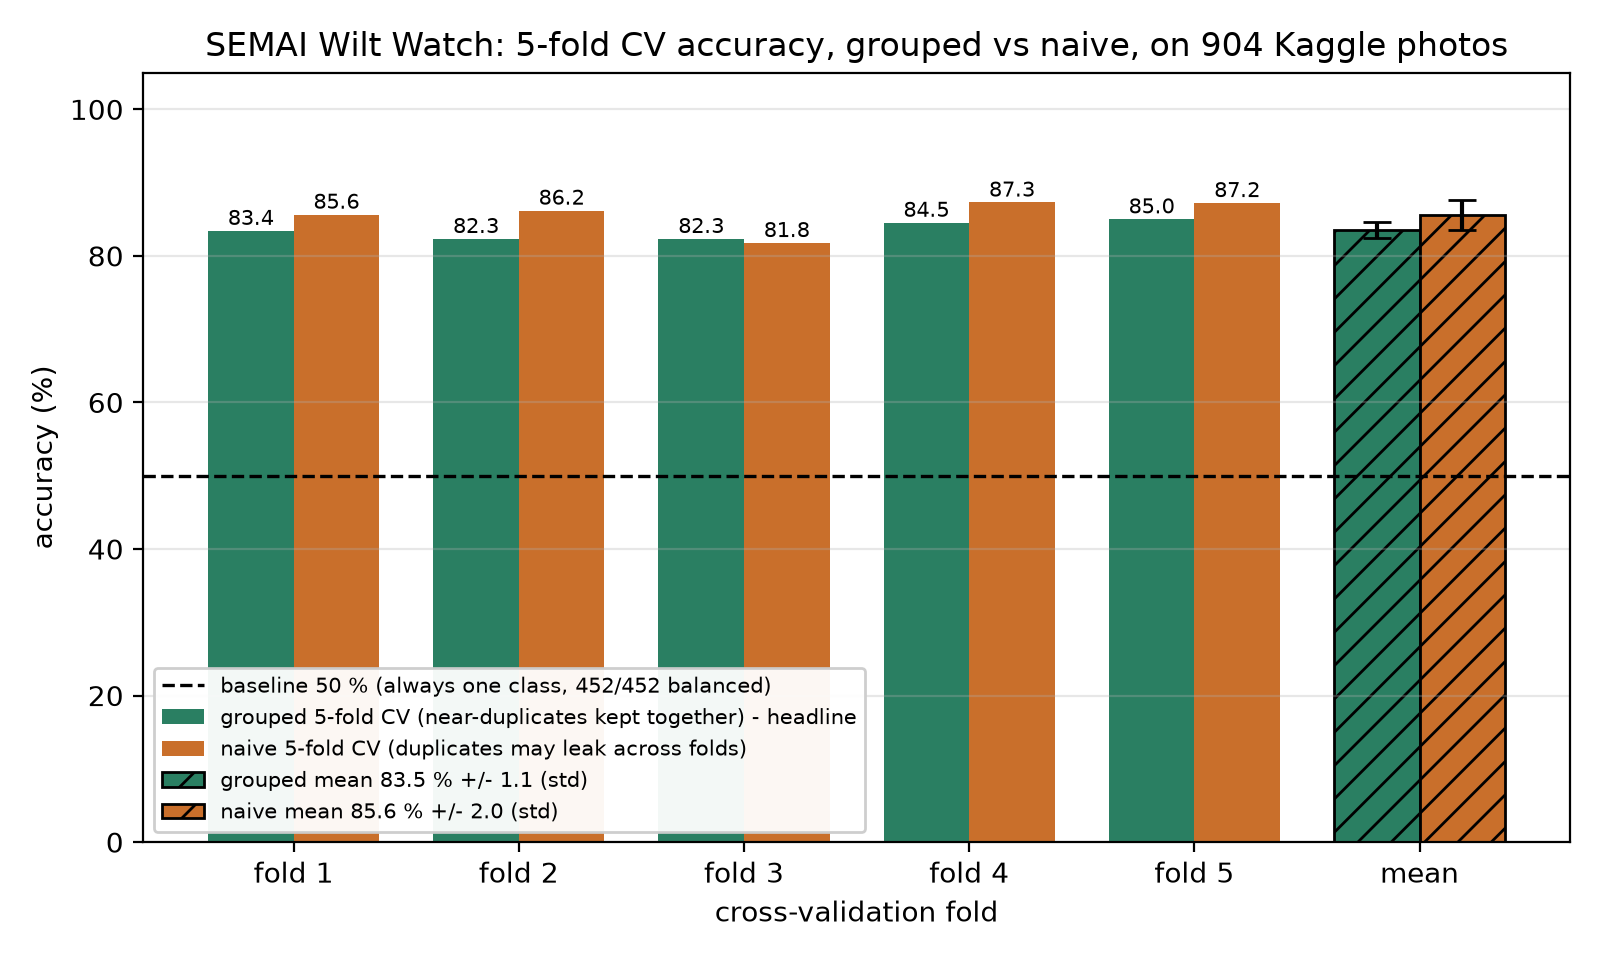

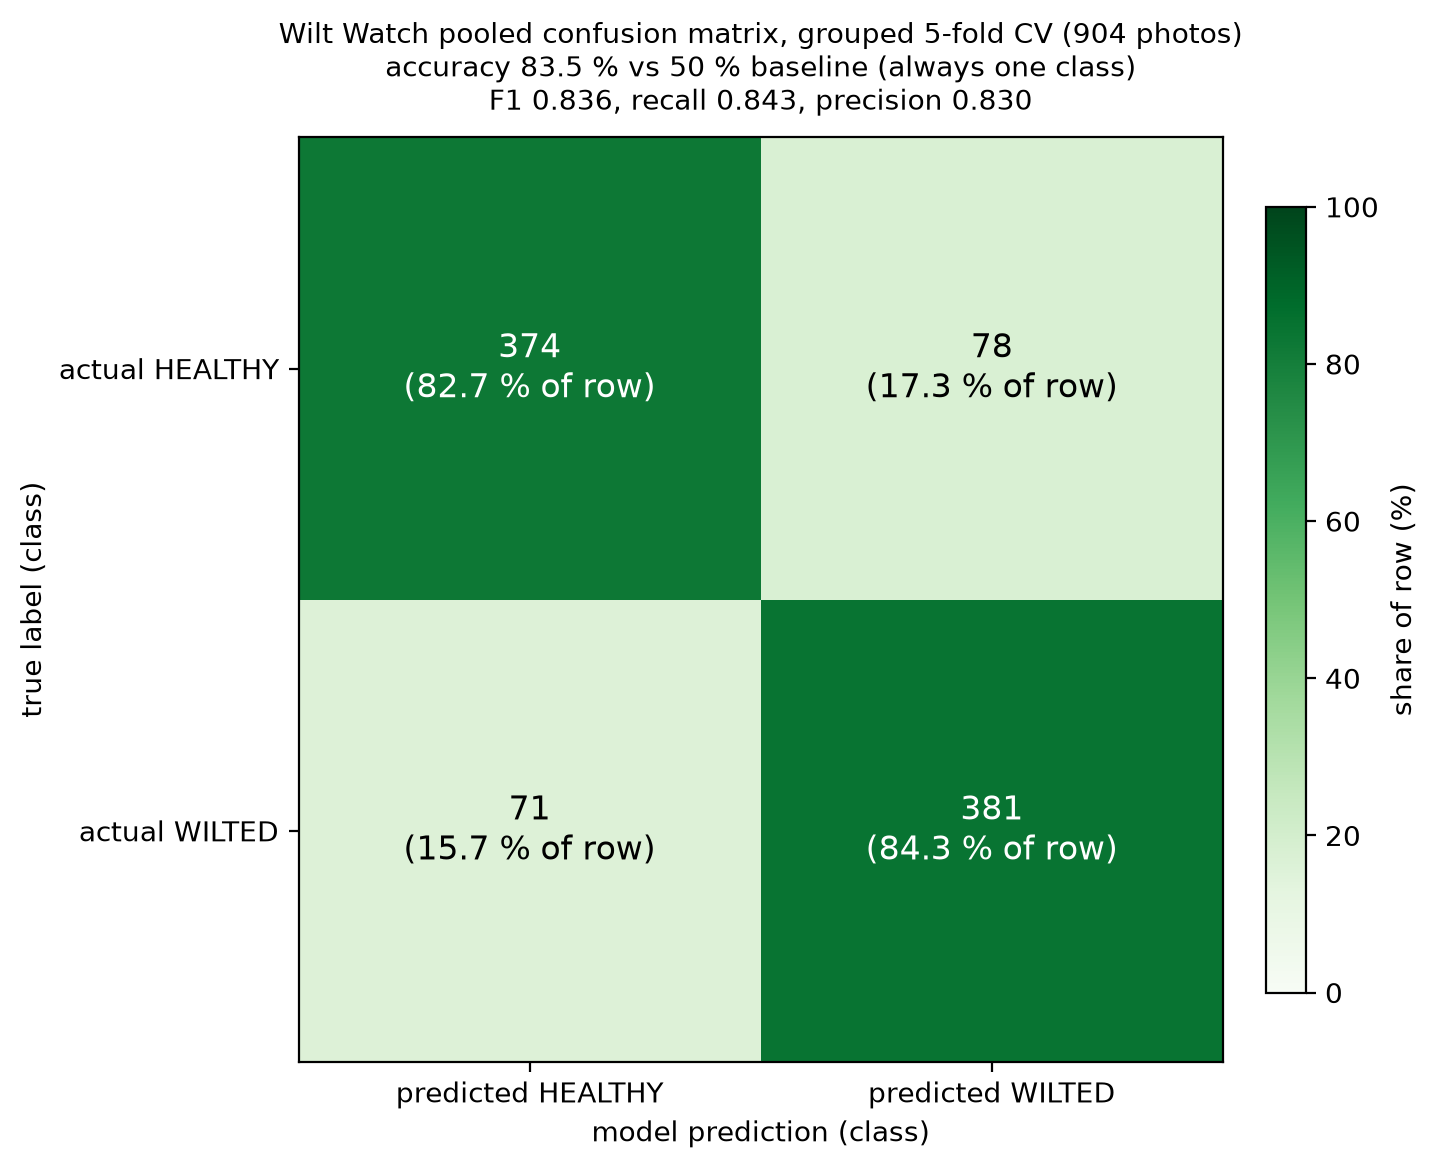

In [8]:
wm = load_json("wilt_metrics.json")
if wm:
    print(json.dumps({k: v for k, v in wm.items() if not isinstance(v, (list, dict))}, indent=1)[:2000])
print(load_json("wilt_rig_eval.json"))
for f in ["R1_wilt_cv_grouped_vs_naive.png", "R2_wilt_confusion.png"]:
    show(f)

## 5 · Today's Penang outlook (refreshes only when online; the console reads the cached file)

In [9]:
run("fetch_today.py", allow_fail=True)
p = os.path.join(ROOT, "data", "today.json")
if os.path.exists(p):
    with open(p, encoding="utf-8") as f:
        t = json.load(f)
    print(t["label"], "fetched", t["fetched_at_local"], "-", len(t["hourly"]), "hours,", sum(1 for h in t["hourly"] if h["dry"]), "dry")
else:
    print("data/today.json missing - run scripts/fetch_today.py while online")

$ python scripts/fetch_today.py    (exit 0, 1 s)
fetch_today: wrote C:\Dev\semai-ml\data\today.json with 72 hours (9 dry) at 2026-09-25 12:40

today's Penang outlook (weather forecast) fetched 2026-09-25 12:40 - 72 hours, 9 dry
